Processing the Digits Dataset with a CNN - 5/4/2026 - derave1577

### Step 1: Load the Dataset

Date: 2026-05-04

Student ID: derave1577

Data shape: (1797, 64)
Number of classes: 10
Classes: [0 1 2 3 4 5 6 7 8 9]
First few row of the data:
[[ 0.  0.  5. 13.  9.  1.  0.  0.  0.  0. 13. 15. 10. 15.  5.  0.  0.  3.
  15.  2.  0. 11.  8.  0.  0.  4. 12.  0.  0.  8.  8.  0.  0.  5.  8.  0.
   0.  9.  8.  0.  0.  4. 11.  0.  1. 12.  7.  0.  0.  2. 14.  5. 10. 12.
   0.  0.  0.  0.  6. 13. 10.  0.  0.  0.]]


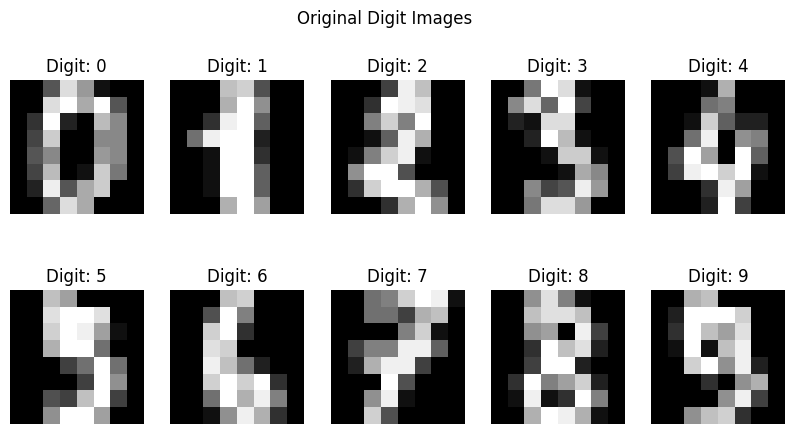

In [1]:
# Import necessary libraries
import os
os.environ["KERAS_BACKEND"] = "torch"
import torch
import keras
from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
import keras_tuner as kt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import pandas as pd
import numpy as np
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from datetime import datetime
from IPython.display import display, Markdown
import matplotlib.pyplot as plt
todays_date = datetime.now().strftime("%Y-%m-%d")
student_id = "derave1577"
# Load the Digits dataset
digits = load_digits()
data = digits.data
target = digits.target
# Display dataset information
display(Markdown("### Step 1: Load the Dataset"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))
print(f"Data shape: {data.shape}")
print(f"Number of classes: {len(np.unique(target))}")
print(f"Classes: {np.unique(target)}")
# Display the first row of the data
print("First few row of the data:")
print(data[:1])
# Display original images
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(digits.images[i], cmap='gray')
    ax.set_title(f"Digit: {target[i]}")
    ax.axis('off')
plt.suptitle('Original Digit Images')
plt.show()

### Step 2: Preprocessing the data

Date: 2026-05-04

Student ID: derave1577

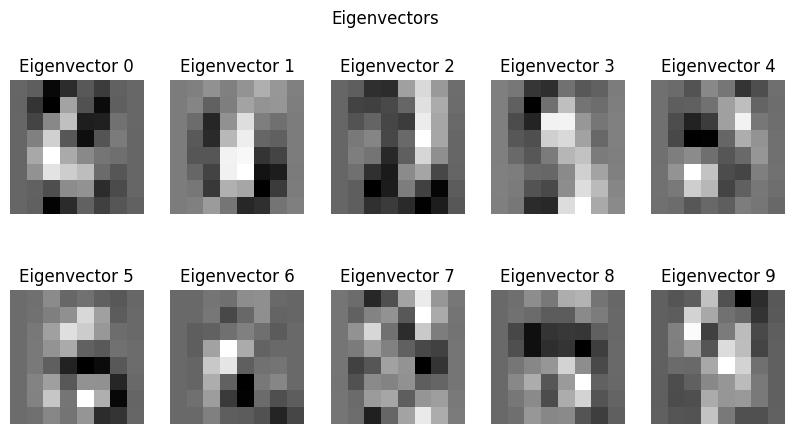

X_train shape: torch.Size([1078, 8, 8, 1])
X_test shape: torch.Size([719, 8, 8, 1])
y_train shape: (1078, 10)
y_test shape: (719, 10)


In [2]:
display(Markdown("### Step 2: Preprocessing the data"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))
# Initialize and fit PCA
pca = PCA(n_components=64)
data_pca = pca.fit_transform(data)
# Display eigenvectors
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
eigenvectors = pca.components_.reshape((64, 8, 8))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(eigenvectors[i], cmap='gray')
    ax.set_title(f"Eigenvector {i}")
    ax.axis('off')
plt.suptitle('Eigenvectors')
plt.show()
# Split the data
X_train, X_test, y_train, y_test = train_test_split(data_pca, target, test_size=0.4, random_state=42)
# Reshape the data
X_train = X_train.reshape(-1, 8, 8, 1)
X_test = X_test.reshape(-1, 8, 8, 1)
# One-hot encode using Keras utilities
y_train_one_hot = to_categorical(y_train, num_classes=10)
y_test_one_hot = to_categorical(y_test, num_classes=10)
# Final conversion to Torch tensors
X_train = keras.ops.convert_to_tensor(X_train)
X_test = keras.ops.convert_to_tensor(X_test)
# Display the shape
print(f"X_train shape: {X_train.shape}")   # (N, 8, 8, 1)
print(f"X_test shape: {X_test.shape}")     # (N, 8, 8, 1)
print(f"y_train shape: {y_train_one_hot.shape}")
print(f"y_test shape: {y_test_one_hot.shape}")

In [3]:
display(Markdown("### Step 3: Construct and Train the CNN Model"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))
# Initialize the model
model = Sequential()
# Add convolutional, pooling, and dense layers
model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(8, 8, 1)))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Flatten())
model.add(Dense(64, activation='relu'))
model.add(Dense(10, activation='softmax'))
# Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['sparse_categorical_accuracy'])
# Display the model summary
model.summary()
# Train the model
history = model.fit(X_train, y_train, epochs=10, validation_data=(X_test, y_test))
# Display the training history
print("Training history:")
print(history.history)

### Step 3: Construct and Train the CNN Model

Date: 2026-05-04

Student ID: derave1577

C:\Users\Derek A\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 6, 6, 32)            │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 3, 3, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 288)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 19,466 (76.04 KB)

 Trainable params: 19,466 (76.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.9159 - sparse_categorical_accuracy: 0.3683 - val_loss: 1.3668 - val_sparse_categorical_accuracy: 0.6120
Epoch 2/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.9961 - sparse_categorical_accuracy: 0.7495 - val_loss: 0.7929 - val_sparse_categorical_accuracy: 0.7942
Epoch 3/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.5931 - sparse_categorical_accuracy: 0.8544 - val_loss: 0.5373 - val_sparse_categorical_accuracy: 0.8428
Epoch 4/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.4074 - sparse_categorical_accuracy: 0.8942 - val_loss: 0.3981 - val_sparse_categorical_accuracy: 0.8873
Epoch 5/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.2822 - sparse_categorical_accuracy: 0.9369 - val_loss: 0.3398 - val_sparse_categorical_accuracy: 0.8915
Epoch 6/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.2207 - sparse_categorical_accuracy: 0.9471 - val_loss: 0.2857 - val_sparse_categorical_accuracy: 0.9096
Epoch 7/10
34/34

### Step 4: Evaluating the Model

Date: 2026-05-04

Student ID: derave1577

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2007 - sparse_categorical_accuracy: 0.9374
Test accuracy: 0.9374130964279175
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


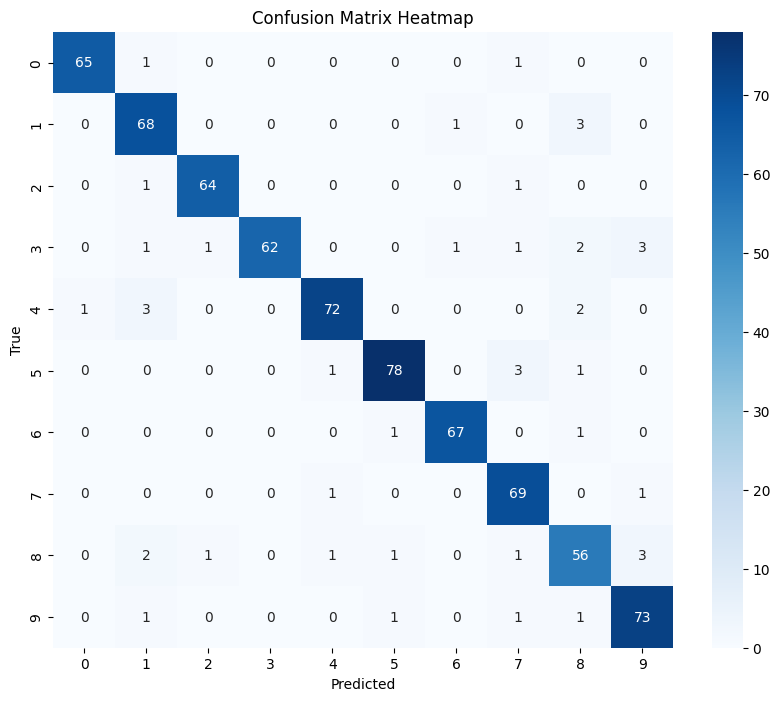

In [4]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
display(Markdown("### Step 4: Evaluating the Model"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))
# Evaluate the model
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test accuracy: {test_acc}")
# Make predictions
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = y_test
# Display the confusion matrix
confusion_mtx = confusion_matrix(y_true, y_pred_classes)
# Plot the confusion matrix as a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_mtx, annot=True, fmt='d', cmap='Blues', xticklabels=digits.target_names, yticklabels=digits.target_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix Heatmap')
plt.show()

In [6]:
import keras_tuner as kt
# Define the hypermodel
def build_model(hp):
    model = Sequential()
    model.add(Conv2D(hp.Int('conv_units', min_value=32, max_value=128, step=32), kernel_size=(3, 3), activation='relu', input_shape=(8, 8, 1)))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Flatten())
    model.add(Dense(hp.Int('dense_units', min_value=64, max_value=256, step=64), activation='relu'))
    model.add(Dense(10, activation='softmax'))
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['sparse_categorical_accuracy'])
    return model
# Initialize the tuner
tuner = kt.Hyperband(build_model, objective='val_sparse_categorical_accuracy', max_epochs=10, factor=3, directory='my_dir', project_name='hyperparam_tuning', overwrite=True)
# Perform hyperparameter search
tuner.search(X_train, y_train, epochs=10, validation_data=(X_test, y_test))
# Get the optimal hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
display(Markdown("### Step 5: Apply Hyperband for CNN Hyperparameter Tuning"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))
print(f"Optimal number of conv_units: {best_hps.get('conv_units')}")
print(f"Optimal number of dense_units: {best_hps.get('dense_units')}")

Trial 22 Complete [00h 00m 01s]
val_sparse_categorical_accuracy: 0.9318497776985168

Best val_sparse_categorical_accuracy So Far: 0.9652295112609863
Total elapsed time: 00h 00m 18s


### Step 5: Apply Hyperband for CNN Hyperparameter Tuning

Date: 2026-05-04

Student ID: derave1577

Optimal number of conv_units: 96
Optimal number of dense_units: 64


### Step 6: Applying the Best Hyperparameters and Evaluate the Tuned CNN Model

Date: 2026-05-04

Student ID: derave1577

Epoch 1/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.4225 - sparse_categorical_accuracy: 0.5751 - val_loss: 0.7558 - val_sparse_categorical_accuracy: 0.8178
Epoch 2/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.5012 - sparse_categorical_accuracy: 0.8924 - val_loss: 0.4072 - val_sparse_categorical_accuracy: 0.8846
Epoch 3/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.2608 - sparse_categorical_accuracy: 0.9481 - val_loss: 0.2718 - val_sparse_categorical_accuracy: 0.9221
Epoch 4/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1682 - sparse_categorical_accuracy: 0.9657 - val_loss: 0.2313 - val_sparse_categorical_accuracy: 0.9360
Epoch 5/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1188 - sparse_categorical_accuracy: 0.9777 - val_loss: 0.1914 - val_sparse_categorical_accuracy: 0.9458
Epoch 6/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0757 - sparse_categorical_accuracy: 0.9898 - val_loss: 0.1631 - val_sparse_categorical_accuracy: 0.9499
Epoch 7/10
34/34

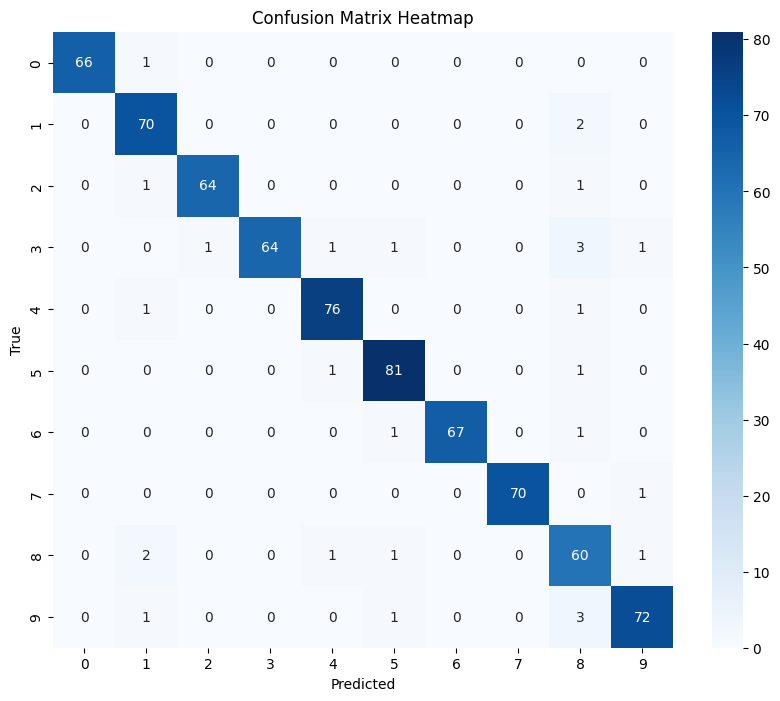

In [7]:
display(Markdown("### Step 6: Applying the Best Hyperparameters and Evaluate the Tuned CNN Model"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))
# Build the model with the best hyperparameters
best_model = Sequential()
best_model.add(Conv2D(best_hps.get('conv_units'), kernel_size=(3, 3), activation='relu', input_shape=(8, 8, 1)))
best_model.add(MaxPooling2D(pool_size=(2, 2)))
best_model.add(Flatten())
best_model.add(Dense(best_hps.get('dense_units'), activation='relu'))
best_model.add(Dense(10, activation='softmax'))
# Compile the model
best_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['sparse_categorical_accuracy'])
# Train the model
best_history = best_model.fit(X_train, y_train, epochs=10, validation_data=(X_test, y_test))
# Evaluate the model
best_test_loss, best_test_acc = best_model.evaluate(X_test, y_test)
print(f"Best Test accuracy: {best_test_acc}")
# Make predictions
best_y_pred = best_model.predict(X_test)
best_y_pred_classes = np.argmax(best_y_pred, axis=1)
best_y_true = y_test
# Display the confusion matrix
best_confusion_mtx = confusion_matrix(best_y_true, best_y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(best_confusion_mtx, annot=True, fmt='d', cmap='Blues', xticklabels=digits.target_names, yticklabels=digits.target_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix Heatmap')
plt.show()

### Step 7: Comparing Tuned vs. Untuned Models

Date: 2026-05-04

Student ID: derave1577

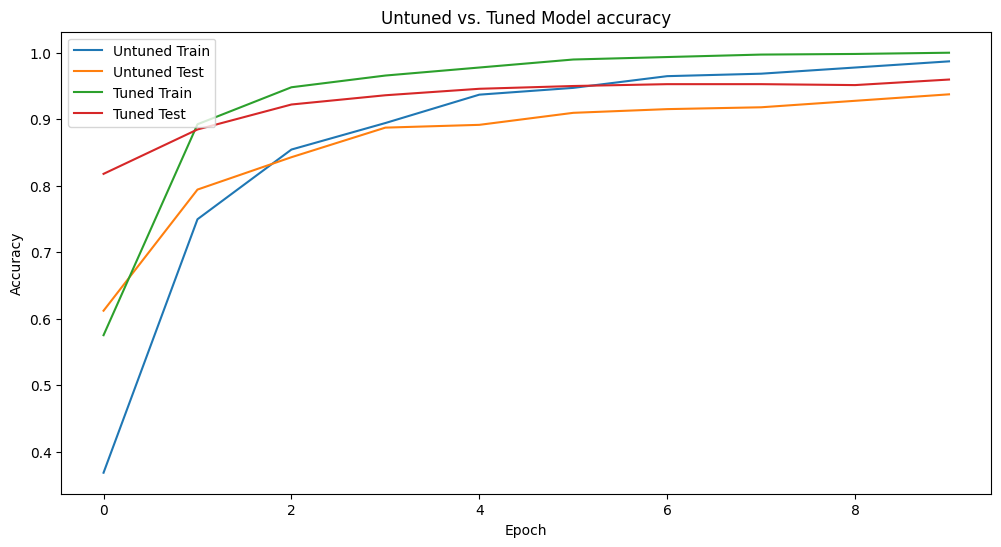

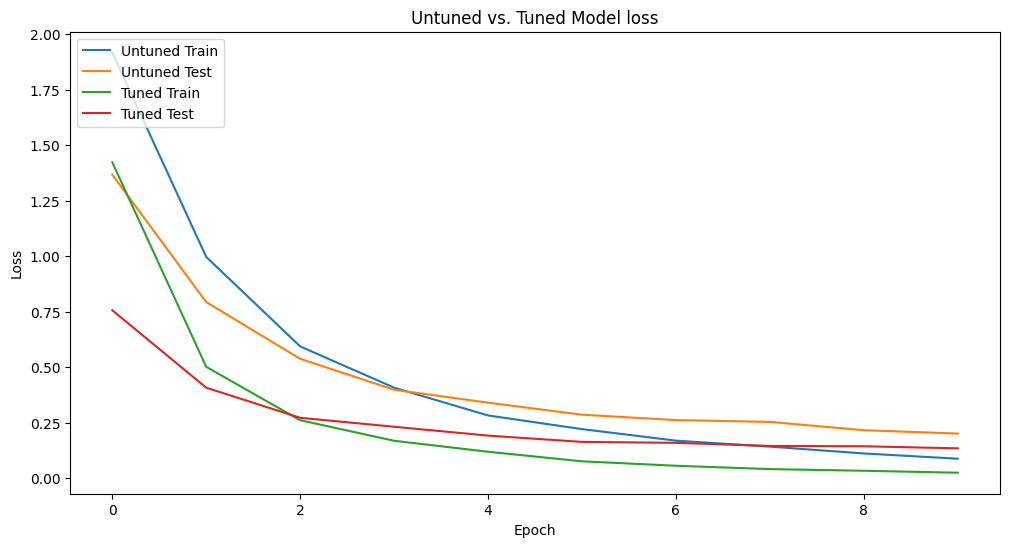

In [11]:
display(Markdown("### Step 7: Comparing Tuned vs. Untuned Models"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))
# Plot training & validation accuracy values
plt.figure(figsize=(12, 6))
plt.plot(history.history['sparse_categorical_accuracy'])
plt.plot(history.history['val_sparse_categorical_accuracy'])
plt.plot(best_history.history['sparse_categorical_accuracy'])
plt.plot(best_history.history['val_sparse_categorical_accuracy'])
plt.title('Untuned vs. Tuned Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Untuned Train', 'Untuned Test', 'Tuned Train', 'Tuned Test'], loc='upper left')
plt.show()
# Plot training & validation loss values
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.plot(best_history.history['loss'])
plt.plot(best_history.history['val_loss'])
plt.title('Untuned vs. Tuned Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Untuned Train', 'Untuned Test', 'Tuned Train', 'Tuned Test'], loc='upper left')
plt.show()